In [1]:
# For this Time series forecasting we used LSTM as they are best to store memory 


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt


In [3]:
dpw = pd.read_csv("C:\\Users\\hp\\OneDrive\\Desktop\\China-Air-pollution-Analysis\\China-Air-pollution-Analysis\\cleaned_pollution_weather.csv", parse_dates=["date"])
dcres = pd.read_csv("C:\\Users\\hp\\OneDrive\\Desktop\\China-Air-pollution-Analysis\\China-Air-pollution-Analysis\\cleaned_cems.csv", parse_dates=["date"])

In [4]:
df = pd.merge(dpw, dcres[['date', 'provorg', 'concentration', 'nfirms_x']], on=["date", "provorg"], how="left")


In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173591 entries, 0 to 173590
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           173591 non-null  datetime64[ns]
 1   provorg        173591 non-null  object        
 2   avg_aqi        173591 non-null  float64       
 3   temp           173591 non-null  float64       
 4   wdsp           173591 non-null  float64       
 5   prcp           173591 non-null  float64       
 6   visib          173591 non-null  float64       
 7   concentration  169733 non-null  float64       
 8   nfirms_x       169733 non-null  float64       
 9   year           173591 non-null  int32         
dtypes: datetime64[ns](1), float64(7), int32(1), object(1)
memory usage: 12.6+ MB


In [13]:
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)


C:\Users\hp\AppData\Local\Temp\ipykernel_20088\3302063104.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_20088\3302063104.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


In [14]:
df = df.sort_values("date").reset_index(drop=True)

In [15]:
features = ["avg_aqi", "temp", "wdsp", "prcp", "visib", "concentration", "nfirms_x"]
df_selected = df[features]

In [16]:
#Normalise Features using MIN Max normaliser
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_selected)

In [17]:
#LSTM  sequence
def create_sequences(data, sequence_length=30):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i])         
        y.append(data[i, 0])                         
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

In [18]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [20]:
# Building the LSTM MOdel
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=64)

Epoch 1/20
2170/2170 ━━━━━━━━━━━━━━━━━━━━ 88s 39ms/step - loss: 0.0060 - val_loss: 7.1112e-04
Epoch 2/20
 304/2170 ━━━━━━━━━━━━━━━━━━━━ 1:05 35ms/step - loss: 0.0028

KeyboardInterrupt: 

1085/1085 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step


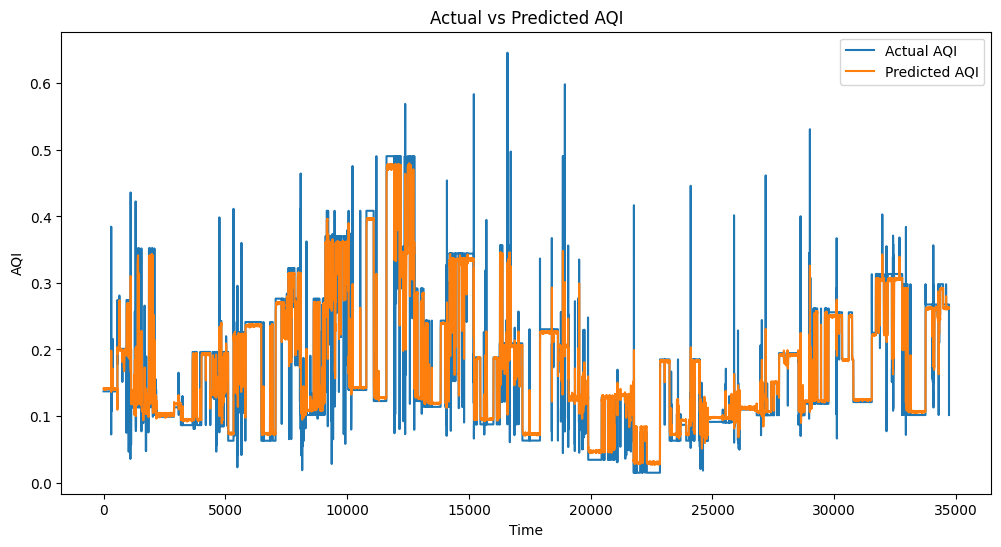

In [ ]:
y_pred = model.predict(X_test)

# Inverse scaling
full_scaler = MinMaxScaler()
full_scaler.fit(df[[target]])
y_test_inv = full_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = full_scaler.inverse_transform(y_pred)

plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual AQI')
plt.plot(y_pred_inv, label='Predicted AQI')
plt.title('Actual vs Predicted AQI')
plt.xlabel('Time')
plt.ylabel('AQI')
plt.legend()
plt.show()


In [93]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("LSTM Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-Squared (R² Score): {r2:.2f}")


LSTM Model Evaluation Metrics:
Mean Absolute Error (MAE): 0.01
Root Mean Squared Error (RMSE): 0.03
R-Squared (R² Score): 0.94


Predicting  & Ranking Provinces by Pollution Levels on future trends using XGBOOST

In [22]:
print(df.columns)


Index(['date', 'provorg', 'avg_aqi', 'temp', 'wdsp', 'prcp', 'visib',
       'concentration', 'nfirms_x', 'year'],
      dtype='object')


In [23]:
df["year"] = df["date"].dt.year


In [24]:
import pandas as pd

df["year"] = df["date"].dt.year  

df_province = df.groupby(["provorg", "year"]).agg({
    "concentration": "mean",  
    "nfirms_x": "sum"         
}).reset_index()

df_province = df_province.sort_values(by=["provorg", "year"])

print(df_province.head())


   provorg  year  concentration  nfirms_x
0    Anhui  2018       0.033801  1.918159
1    Anhui  2019       0.033262  2.173913
2    Anhui  2020       0.012416  0.140665
3  Beijing  2018       0.011218  0.000000
4  Beijing  2019       0.011218  0.000000


In [25]:
# Create lag features (previous year's pollution levels)
df_province["prev_concentration"] = df_province.groupby("provorg")["concentration"].shift(1)
df_province = df_province.dropna()  


In [26]:
# Training XGBoost Model

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

features = ["prev_concentration", "nfirms_x"]
target = "concentration"

X_train, X_test, y_train, y_test = train_test_split(df_province[features], df_province[target], test_size=0.2, random_state=42)

model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")


RMSE: 0.03


In [27]:
# Predicting next year plollution and ranking the data 
df_province["pred_concentration"] = model.predict(df_province[features])

df_ranked = df_province[df_province["year"] == df_province["year"].max()]
df_ranked = df_ranked.sort_values(by="pred_concentration", ascending=False)

print(df_ranked[["provorg", "pred_concentration"]].head(10))


           provorg  pred_concentration
35           Henan            0.373713
32    Heilongjiang            0.335921
38           Hubei            0.286210
56        Liaoning            0.243798
62         Qinghai            0.238482
59         Ningxia            0.238482
65         Shaanxi            0.167614
92        Zhejiang            0.102671
68        Shandong            0.083301
44  Inner Mongolia            0.066306


In [28]:
print(df_province.groupby('provorg')['year'].nunique())


provorg
Anhui             2
Beijing           2
Chongqing         2
Fujian            2
Gansu             2
Guangdong         2
Guangxi           2
Guizhou           2
Hainan            2
Hebei             2
Heilongjiang      2
Henan             2
Hubei             2
Hunan             2
Inner Mongolia    2
Jiangsu           2
Jiangxi           2
Jilin             2
Liaoning          2
Ningxia           2
Qinghai           2
Shaanxi           2
Shandong          2
Shanghai          2
Shanxi            2
Sichuan           2
Tianjin           2
Tibet             2
Xinjiang          2
Yunnan            2
Zhejiang          2
Name: year, dtype: int64


C:\Users\hp\AppData\Local\Temp\ipykernel_20088\3484059551.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['year'] = filtered_df['year'].astype(int)


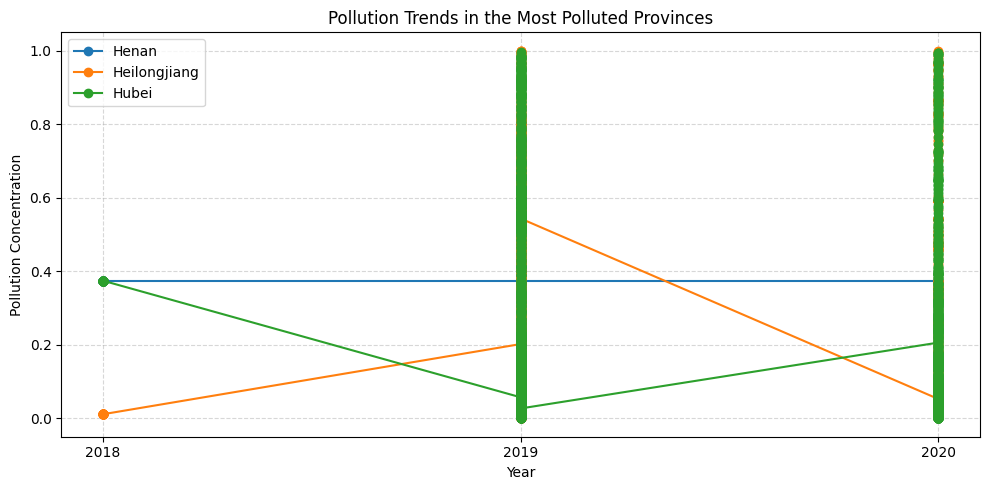

In [29]:
# Filter only necessary provinces and years
top_provinces = df_ranked["provorg"].head(3).tolist()
filtered_df = df[df['provorg'].isin(top_provinces)]

# Ensure year is integer
filtered_df['year'] = filtered_df['year'].astype(int)

# Plot
plt.figure(figsize=(10, 5))
for province in top_provinces:
    data = filtered_df[filtered_df["provorg"] == province]
    plt.plot(data["year"], data["concentration"], marker="o", label=province)

plt.xlabel("Year")
plt.ylabel("Pollution Concentration")
plt.title("Pollution Trends in the Most Polluted Provinces")
plt.xticks(sorted(filtered_df["year"].unique()))  # sorted ticks
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


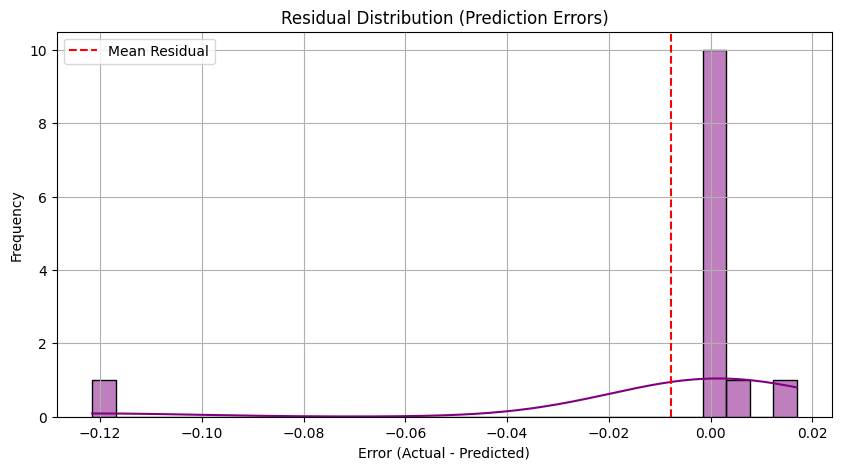

In [129]:
# Prediction error analysis
residuals = y_test_flat - y_pred_flat
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, bins=30, color="purple")
plt.axvline(residuals.mean(), color="red", linestyle="dashed", label="Mean Residual")
plt.title("Residual Distribution (Prediction Errors)")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [134]:
# Extract feature importances
importance_dict = model.get_booster().get_score(importance_type='gain')

importance_df = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Importance': list(importance_dict.values())
})

importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# top 20 features
top_features_df = importance_df.head(5)
print(top_features_df)


              Feature  Importance
0  prev_concentration    0.004664
1            nfirms_x    0.001383


C:\Users\hp\AppData\Local\Temp\ipykernel_28952\123289297.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features_df, y='Feature', x='Importance', palette='viridis')


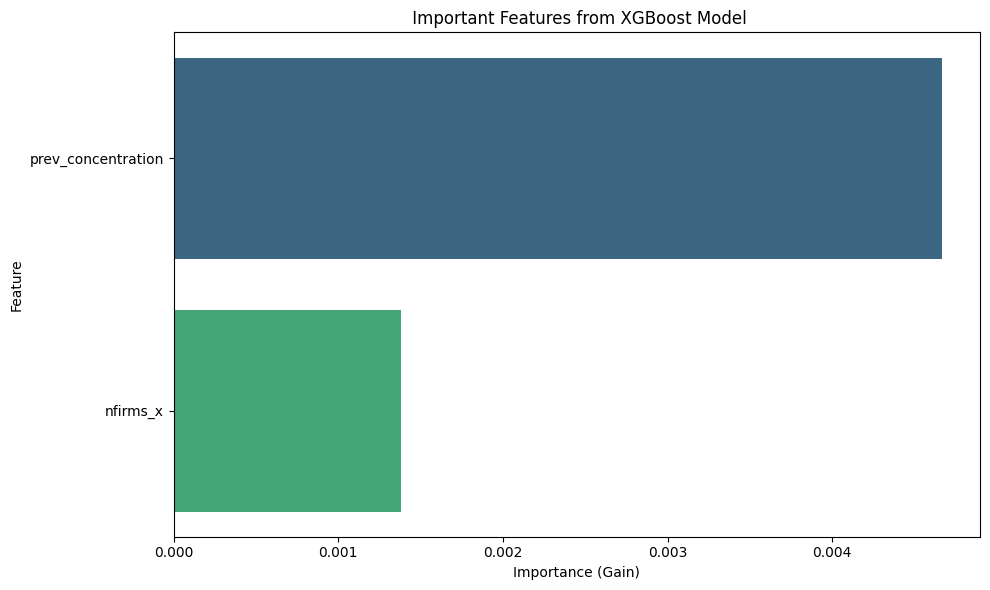

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features_df, y='Feature', x='Importance', palette='viridis')
plt.title(' Important Features from XGBoost Model')
plt.xlabel('Importance (Gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [49]:
df_model = df.copy()  # assuming your original dataframe is named df
df_model = df_model.sort_values(['provorg', 'year'])

df_model['prev_concentration'] = df_model.groupby('provorg')['concentration'].shift(1)
df_model = df_model.dropna(subset=['prev_concentration'])


In [56]:
future_years = [2021, 2022, 2023, 2024, 2025]
future_predictions = []

for province in df_model['provorg'].unique():
    last_known = df_model[df_model['provorg'] == province].sort_values('year').iloc[-1]
    prev_concentration = last_known['concentration']
    nfirms = last_known['nfirms_x']

    for year in future_years:
        X_future = pd.DataFrame([{
            'prev_concentration': prev_concentration,
            'nfirms_x': nfirms
        }])

        predicted_concentration = model.predict(X_future)[0]

        future_predictions.append({
            'year': year,
            'provorg': province,
            'predicted_concentration': predicted_concentration
        })

        prev_concentration = predicted_concentration


In [57]:
future_df = pd.DataFrame(future_predictions)


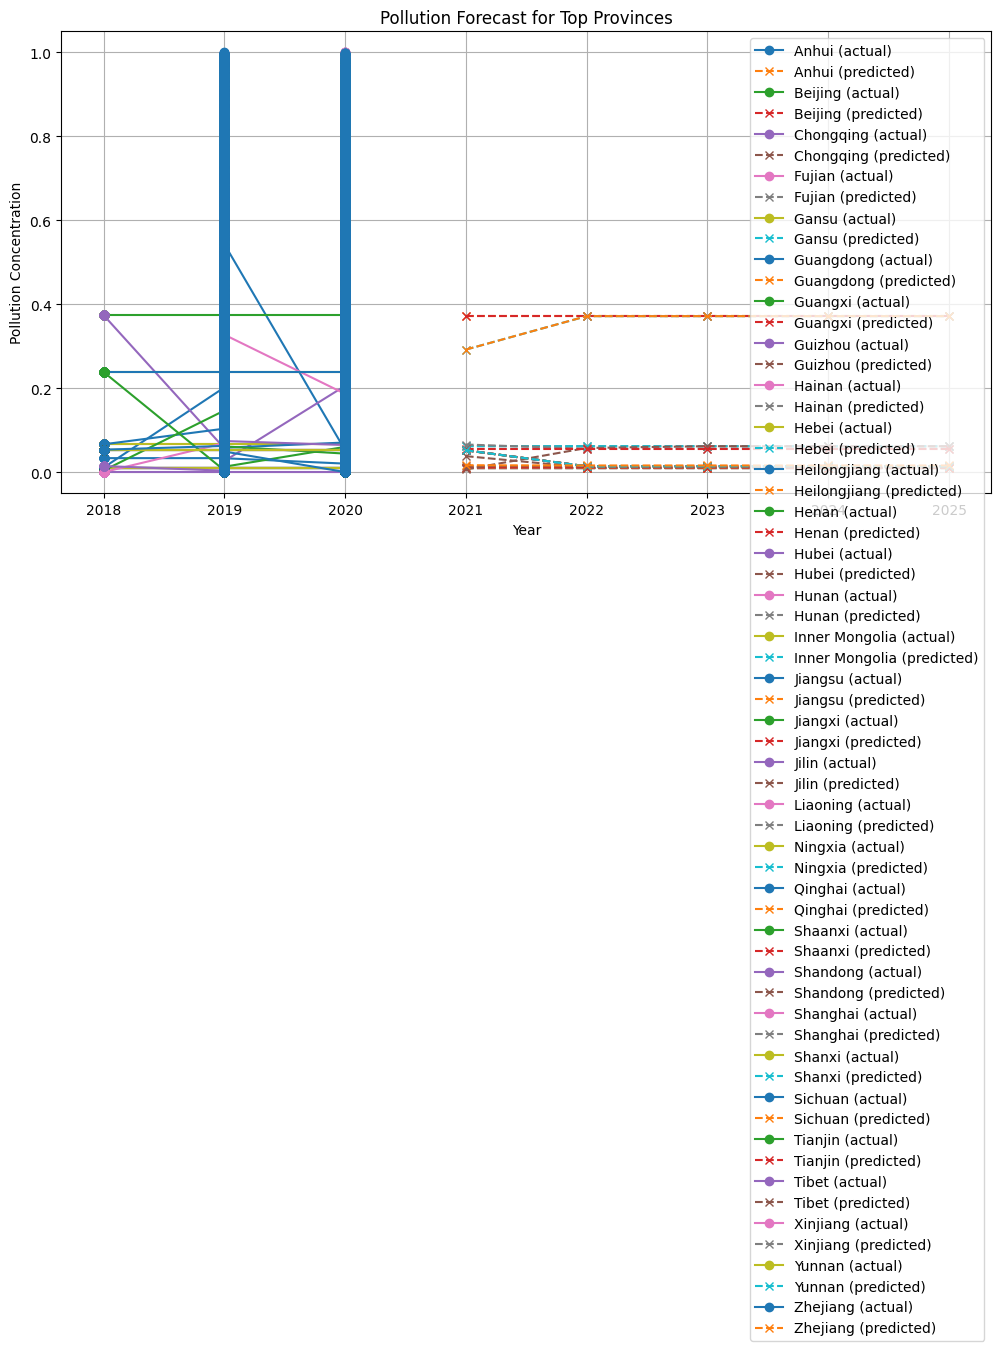

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for province in df_model['provorg'].unique():
    actual_data = df_model[df_model['provorg'] == province]
    predicted_data = future_df[future_df['provorg'] == province]

    plt.plot(actual_data['year'], actual_data['concentration'], marker='o', label=f'{province} (actual)')
    plt.plot(predicted_data['year'], predicted_data['predicted_concentration'], linestyle='--', marker='x', label=f'{province} (predicted)')

plt.xlabel('Year')
plt.ylabel('Pollution Concentration')
plt.title('Pollution Forecast for Top Provinces')
plt.legend()
plt.grid(True)
plt.show()
